In [1]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats=['svg']
import time
import pandas as pd

import torch.optim as optim
import torch 
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml, fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


from model import Model1, Model2, RLoss
# for traning
from utility import train_epoch_sgd, train_epoch_lbfgs, train_batch
# for evaluating 
from utility import acc, baseline, evaluate_batch

from adamw import AdamW

In [2]:
SEED = 42 
N_EPOCHS = 40
INIT_MAX = 3
BATCH_SIZE = 64
# on cpu works faster
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer_names = ["Adam", "Adam_ExpLR", "Nadam", "AdamW", "Amsgrad"]

In [3]:
def select_adam_optimizer(model, optimizer_name="Adam", batch_size=64, learning_rate=0.001):
            
    if optimizer_name.lower() == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate) 
        
    elif optimizer_name.lower() == "adam_explr":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)  
        return optimizer, scheduler
        
    elif optimizer_name.lower() == "nadam":
        optimizer = optim.NAdam(model.parameters(), lr=learning_rate)
        
    elif optimizer_name.lower() == "adamw":
        optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-2)
        
    elif optimizer_name.lower() == "amsgrad":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, amsgrad=True)
    else:
        raise ValueError(f"We don't consider {optimizer_name}")
    
    return optimizer, None


## A9a dataset 

In [13]:
a9a = fetch_openml(name='a9a', version=1)
X = a9a.data  
y = a9a.target
X = X.toarray()

y = (y == np.float64(1.0)).astype(np.float32)   
y = torch.FloatTensor(y)  
y = y.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)

X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

y_train_tensor = torch.FloatTensor(y_train)
y_test_tensor = torch.FloatTensor(y_test)


train_dataset = TensorDataset(X_train_tensor, y_train)
test_dataset = TensorDataset(X_test_tensor, y_test)

print("Train size: ", X_train.shape, "Test size:", X_test.shape)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

results_for_a9a = {} 

Train size:  (34189, 123) Test size: (14653, 123)


In [14]:
is_binary = True

for optimizer in optimizer_names:
    print(f"Optimizer: {optimizer}")
    
    # initialize arrays for metrics 
    metrics = {
        'train_loss': np.zeros((INIT_MAX, N_EPOCHS)),
        'test_loss': np.zeros((INIT_MAX, N_EPOCHS)),
        'test_acc': np.zeros((INIT_MAX, N_EPOCHS))
    }
    training_times = []
    
    # averaging over initializations 
    for i in range(INIT_MAX):
        # Set seeds
        torch.manual_seed(SEED + i)
        np.random.seed(SEED + i)
        
        # Initialize model
        if is_binary:
            loss_fun = nn.BCEWithLogitsLoss()
            model = Model1(X_train.shape[1])
        else: 
            loss_fun = nn.CrossEntropyLoss()
            model = Model2(X_train.shape[1])
        
        opt, sched = select_adam_optimizer(model, optimizer)
        
        total_time = 0
        
        
        # Training loop
        for epoch in range(N_EPOCHS):
            start_time = time.perf_counter()
            
            train_loss, test_loss, test_accuracy = train_epoch_sgd(
                        model, opt, loss_fun, train_loader, test_loader, device, sched, is_binary)
            
            metrics['train_loss'][i, epoch] = train_loss
            metrics['test_loss'][i, epoch] = test_loss
            metrics['test_acc'][i, epoch] = test_accuracy
            
            epoch_time = time.perf_counter() - start_time
            total_time += epoch_time
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch+1} - Train: {train_loss:.4f}, Test: {test_loss:.4f}, Time: {epoch_time:.2f}s")
        
        training_times.append(total_time)
        print(f"Instance {i} - Total time: {total_time:.2f}s")
        print("--------------------------------")
    

    results_for_a9a[optimizer] = {
        "average_train_loss": metrics['train_loss'].mean(axis=0).tolist(),
        "average_test_loss": metrics['test_loss'].mean(axis=0).tolist(),
        "test_acc": metrics['test_acc'].mean(axis=0).tolist(),
        "training_time": float(np.mean(training_times))
    }


Optimizer: Adam
Epoch 1 - Train: 0.4595, Test: 0.3782, Time: 0.55s
Epoch 11 - Train: 0.3233, Test: 0.3273, Time: 0.52s
Epoch 21 - Train: 0.3224, Test: 0.3277, Time: 0.54s
Epoch 31 - Train: 0.3221, Test: 0.3281, Time: 0.51s
Instance 0 - Total time: 22.24s
--------------------------------
Epoch 1 - Train: 0.4675, Test: 0.3833, Time: 0.52s
Epoch 11 - Train: 0.3230, Test: 0.3276, Time: 0.54s
Epoch 21 - Train: 0.3222, Test: 0.3277, Time: 0.52s
Epoch 31 - Train: 0.3219, Test: 0.3281, Time: 0.55s
Instance 1 - Total time: 21.69s
--------------------------------
Epoch 1 - Train: 0.4653, Test: 0.3820, Time: 0.55s
Epoch 11 - Train: 0.3235, Test: 0.3274, Time: 0.59s
Epoch 21 - Train: 0.3224, Test: 0.3277, Time: 0.61s
Epoch 31 - Train: 0.3221, Test: 0.3281, Time: 0.55s
Instance 2 - Total time: 23.26s
--------------------------------
Optimizer: Adam_ExpLR
Epoch 1 - Train: 0.4595, Test: 0.3782, Time: 0.57s
Epoch 11 - Train: 0.3238, Test: 0.3272, Time: 0.57s
Epoch 21 - Train: 0.3226, Test: 0.3273, Tim

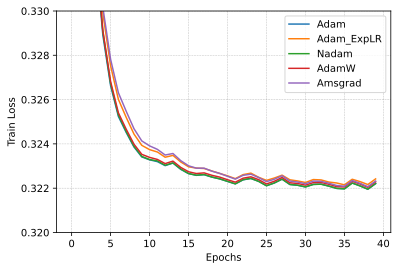

In [17]:
fig = plt.figure(figsize=(6, 4))
for method, metrics in results_for_a9a.items():
    plt.plot(metrics["average_train_loss"], label=f'{method}')

plt.xlabel('Epochs')
plt.ylabel('Train Loss')
plt.ylim(0.32, 0.33)
# plt.yscale('log')
plt.legend()
plt.grid(linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig("plots/Train Loss vs Epochs Adams A9a.png", dpi=fig.dpi)
plt.show()

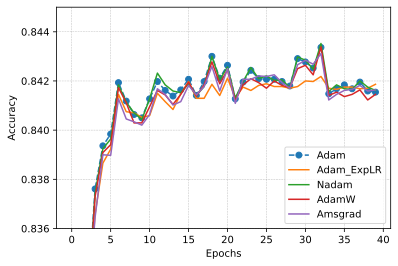

In [18]:
fig = plt.figure(figsize=(6, 4))
for method, metrics in results_for_a9a.items():
    if method == "Adam":
        plt.plot(metrics["test_acc"], 'o--', label=f'{method}')
    else:
        plt.plot(metrics["test_acc"], label=f'{method}')

#plt.plot(np.arange(0,N_EPOCHS), [base_acc]*N_EPOCHS,'--', label=f'baseline')
plt.ylim(0.836, 0.845)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig("plots/Test ACC vs Epochs Adams A9a.png", dpi=fig.dpi)
plt.show()

## Covtype

In [4]:
covtype = fetch_covtype()
X = covtype.data
y = torch.LongTensor(covtype.target-1)  # Convert to 0-6 range

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)

X_train_scaled =  torch.FloatTensor(scaler.fit_transform(X_train[:,0:10])) #the rest are binary features
X_test_scaled = torch.FloatTensor(scaler.transform(X_test[:,0:10]) )

X_train_binary = torch.FloatTensor(X_train[:, 10:])
X_test_binary = torch.FloatTensor(X_test[:, 10:])

X_train_tensor = torch.cat((X_train_scaled, X_train_binary), dim=1)
X_test_tensor = torch.cat((X_test_scaled, X_test_binary), dim=1)

y_train_tensor = torch.clone(y_train) # for consistency 
y_test_tensor = torch.clone(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

print("Train size: ", X_train.shape, "Test size:", X_test.shape)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

results_for_covtype = {}

Train size:  (406708, 54) Test size: (174304, 54)


In [5]:
is_binary = False

for optimizer in optimizer_names:
    print(f"Optimizer: {optimizer}")
    
    # initialize arrays for metrics 
    metrics = {
        'train_loss': np.zeros((INIT_MAX, N_EPOCHS)),
        'test_loss': np.zeros((INIT_MAX, N_EPOCHS)),
        'test_acc': np.zeros((INIT_MAX, N_EPOCHS))
    }
    training_times = []
    
    # averaging over initializations 
    for i in range(INIT_MAX):
        # Set seeds
        torch.manual_seed(SEED + i)
        np.random.seed(SEED + i)
        
        # Initialize model
        if is_binary:
            loss_fun = nn.BCEWithLogitsLoss()
            model = Model1(X_train.shape[1])
        else: 
            loss_fun = nn.CrossEntropyLoss()
            model = Model2(X_train.shape[1])
        
        opt, sched = select_adam_optimizer(model, optimizer)
        
        total_time = 0
        
        
        # Training loop
        for epoch in range(N_EPOCHS):
            start_time = time.perf_counter()
            
            train_loss, test_loss, test_accuracy = train_epoch_sgd(
                        model, opt, loss_fun, train_loader, test_loader, device, sched, is_binary)
            
            metrics['train_loss'][i, epoch] = train_loss
            metrics['test_loss'][i, epoch] = test_loss
            metrics['test_acc'][i, epoch] = test_accuracy
            
            epoch_time = time.perf_counter() - start_time
            total_time += epoch_time
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch+1} - Train: {train_loss:.4f}, Test: {test_loss:.4f}, Time: {epoch_time:.2f}s")
        
        training_times.append(total_time)
        print(f"Instance {i} - Total time: {total_time:.2f}s")
        print("--------------------------------")
    

    results_for_covtype[optimizer] = {
        "average_train_loss": metrics['train_loss'].mean(axis=0).tolist(),
        "average_test_loss": metrics['test_loss'].mean(axis=0).tolist(),
        "test_acc": metrics['test_acc'].mean(axis=0).tolist(),
        "training_time": float(np.mean(training_times))
    }


Optimizer: Adam
Epoch 1 - Train: 0.7548, Test: 0.6618, Time: 6.11s
Epoch 11 - Train: 0.6309, Test: 0.6330, Time: 6.91s
Epoch 21 - Train: 0.6294, Test: 0.6318, Time: 6.92s
Epoch 31 - Train: 0.6291, Test: 0.6319, Time: 7.63s
Instance 0 - Total time: 289.35s
--------------------------------
Epoch 1 - Train: 0.7603, Test: 0.6609, Time: 7.66s
Epoch 11 - Train: 0.6308, Test: 0.6332, Time: 7.29s
Epoch 21 - Train: 0.6294, Test: 0.6318, Time: 7.29s
Epoch 31 - Train: 0.6291, Test: 0.6316, Time: 7.07s
Instance 1 - Total time: 290.24s
--------------------------------
Epoch 1 - Train: 0.7525, Test: 0.6610, Time: 6.78s
Epoch 11 - Train: 0.6308, Test: 0.6328, Time: 7.35s
Epoch 21 - Train: 0.6294, Test: 0.6320, Time: 6.69s
Epoch 31 - Train: 0.6291, Test: 0.6317, Time: 6.79s
Instance 2 - Total time: 274.41s
--------------------------------
Optimizer: Adam_ExpLR
Epoch 1 - Train: 0.7548, Test: 0.6618, Time: 6.82s
Epoch 11 - Train: 0.6315, Test: 0.6336, Time: 6.80s
Epoch 21 - Train: 0.6297, Test: 0.6322, 

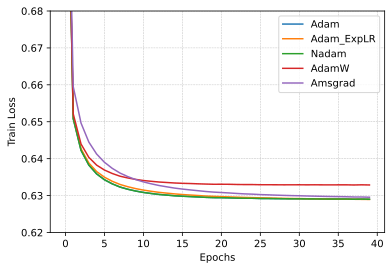

In [8]:
fig = plt.figure(figsize=(6, 4))
for method, metrics in results_for_covtype.items():
    plt.plot(metrics["average_train_loss"], label=f'{method}')

plt.xlabel('Epochs')
plt.ylabel('Train Loss')
plt.ylim(0.62, 0.68)
# plt.yscale('log')
plt.legend()
plt.grid(linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig("plots/Train Loss vs Epochs Adams Covtype.png", dpi=fig.dpi)
plt.show()

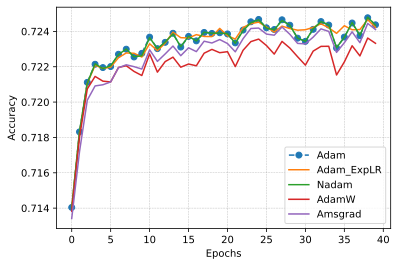

In [9]:
fig = plt.figure(figsize=(6, 4))
for method, metrics in results_for_covtype.items():
    if method == "Adam":
        plt.plot(metrics["test_acc"], 'o--', label=f'{method}')
    else:
        plt.plot(metrics["test_acc"], label=f'{method}')

#plt.plot(np.arange(0,N_EPOCHS), [base_acc]*N_EPOCHS,'--', label=f'baseline')
# plt.ylim(0.836, 0.845)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig("plots/Test ACC vs Epochs Adams Covtype.png", dpi=fig.dpi)
plt.show()